<a href="https://colab.research.google.com/github/kaileesegarra/dermatology-no-show-analysis/blob/main/Final_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[View Project Website](https://kaileesegarra.github.io/dermatology-no-show-analysis/)

# Predicting Medical Appointment No-Shows with Logistic Regression

**Kailee Segarra**  
*CMPS 6790 — Data Science*

---

## Data Science Lifecycle Roadmap

This project follows a structured data science workflow to move from problem definition to actionable insights:

### 1. Question and Motivation  
Why missed appointments matter and how data science can help address this challenge.

### 2. Data Collection  
Where the appointment data originates and how it is accessed for analysis.

### 3. Data Cleaning & Feature Engineering  
How raw appointment records are transformed into clean, model-ready variables.

### 4. Exploratory Data Analysis (EDA)  
What patterns and relationships emerge before modeling.

### 5. Modeling and Testing  
Building and evaluating a logistic regression model using a train/test framework.

### 6. Conclusions and Recommendations  
Key findings and how healthcare teams can apply these insights responsibly.

## 1. Question and Motivation

Missed medical appointments are both a **practical healthcare challenge** and a compelling **data science problem**. In clinical settings, no-shows lead to unused appointment slots, longer wait times, delayed care, and inefficiencies for providers and staff. From a patient perspective, missing an appointment can delay diagnosis, treatment, medication refills, or follow-up care.

This issue is especially relevant in outpatient specialties such as dermatology, where patients may be monitoring changing lesions, chronic inflammatory conditions, post-procedure healing, or medication side effects.

---

### Central Question

> **Can appointment scheduling, reminder, demographic, and neighborhood-level variables help predict whether a patient will miss a medical appointment?**

---

### Why This is a Data Science Problem

This question is well-suited for data science because the outcome is:
- **measurable** (attendance vs. no-show)  
- **binary** (classification task)  
- **operationally meaningful** for real-world decision-making  

Each appointment record can be labeled as attended or missed, allowing the problem to be framed as a **supervised classification task**. Rather than replacing human judgment, the goal is to uncover patterns that can support better scheduling workflows, reminder strategies, and patient outreach.

---

### Project Context

This final tutorial builds on exploratory work from Milestones 1 and 2. Peer and instructor feedback emphasized the need to move beyond descriptive analysis and demonstrate **model implementation, testing, and evaluation**.

As a result, this project:
- uses **EDA to motivate feature selection**
- builds a **logistic regression model**
- evaluates performance on unseen test data  

---

### Data Science Perspective

From a data science standpoint, this problem fits naturally into a **supervised learning framework**, where historical appointment data is used to predict future attendance outcomes.

When applied thoughtfully, this type of modeling can support more efficient clinic operations, improve patient access to care, and enable data-informed decision-making in healthcare settings.

## 2. Resources and Data Sources

### Primary Dataset
- **[Brazilian Medical Appointment No-Show Dataset (Kaggle)](https://www.kaggle.com/datasets/joniarroba/noshowappointments)**  

This dataset contains more than 100,000 appointment records from Brazil's public healthcare system. It includes demographic variables, appointment scheduling information, neighborhood, scholarship status, health condition indicators, SMS reminder status, and a final attendance outcome.

---

### Helpful Conceptual Resources
- **[Scikit-learn Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)**  
- **[Scikit-learn Model Evaluation Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)**  
- **[Train/Test Split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)**  
- **[Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)**  

These resources provide foundational understanding of the modeling techniques and evaluation methods used in this project.

---

### Supplemental Dataset Note
Milestone 2 used a small manually constructed socioeconomic dataset by neighborhood. For the final project, this is treated as **illustrative only** unless the dataset is made publicly available. To ensure full reproducibility, the final model relies on the Kaggle dataset. Future work could incorporate validated and publicly available socioeconomic data sources.

---

### Real-World Context
A practical overview of how machine learning is used in healthcare to predict no-shows and improve scheduling efficiency can be found here:  
- **[How Machine Learning Can Predict Patient No-Shows (AAPC)](https://www.aapc.com/blog/93112-can-machine-learning-predict-patient-no-shows/)**  

This article provides real-world context for how predictive models are used to identify high-risk patients and support proactive scheduling and reminder strategies.

In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [2]:
# Consistent lavender theme for all project visuals
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#3B0A57",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "text.color": "#333333",
    "grid.color": "#E8DFF0",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10,
})

dark_purple = "#3B0A57"
mid_purple = "#9B6BB6"
bar_purple = "#B58BD0"
light_purple = "#E5D8F0"

purple_palette = [
    "#E6D9F2",
    "#D6BFE6",
    "#C5A3D8",
    "#B184C7",
    "#9B63B6",
    "#874FA6"
]

## 3. Data Collection and Loading

The dataset is loaded from a public GitHub copy of the Kaggle Medical Appointment No-Show dataset so the notebook can be rerun without manual uploads.

In [3]:
# Load the appointment dataset
url = "https://raw.githubusercontent.com/ksatola/Medical-Appointments-No-Shows/master/noshowappointments-kagglev2-may-2016.csv"

df = pd.read_csv(url)

# Preview the raw data
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
# Show basic dataset shape and column information
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.info()

Rows: 110,527
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


## 4. Data Cleaning and Feature Engineering

The raw dataset is already structured in a **tidy format**, with one row per appointment. However, several transformations are required before the data can be used for analysis and modeling.

---

### Data Cleaning

The following preprocessing steps are applied:

- Standardize column names for consistency  
- Convert date columns to proper datetime format  
- Handle invalid or implausible values (e.g., negative lead times, unrealistic ages)  
- Create a binary target variable representing appointment attendance  

---

### Feature Engineering

New features are created to better capture patterns in patient behavior and scheduling:

- **`lead_time_days`** — number of days between scheduling and the appointment  
- **`appointment_weekday`** — day of the week for the appointment  
- **`scheduled_hour`** — time of day the appointment was scheduled  
- **Grouped features** such as age groups and delay categories for exploratory analysis  

---

### Key Feature: Scheduling Delay

The most important engineered feature is **`lead_time_days`**, which measures the time between when an appointment is scheduled and when it occurs.

This feature is directly motivated by exploratory analysis, which suggests that **longer scheduling delays are associated with higher no-show rates**. As a result, `lead_time_days` is not only a descriptive variable, but also a **theoretically meaningful predictor** of patient attendance behavior.

In [5]:
# Standardize column names
clean_df = df.copy()
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace('-', '_')
)

# Convert dates
clean_df['scheduledday'] = pd.to_datetime(clean_df['scheduledday'])
clean_df['appointmentday'] = pd.to_datetime(clean_df['appointmentday'])

# Binary target: 1 = missed appointment, 0 = attended appointment
clean_df['no_show_flag'] = (clean_df['no_show'] == 'Yes').astype(int)

# Appointment lead time in days
clean_df['lead_time_days'] = (
    clean_df['appointmentday'].dt.date.astype('datetime64[ns]') -
    clean_df['scheduledday'].dt.date.astype('datetime64[ns]')
).dt.days

# Replace impossible negative lead times with missing values
clean_df.loc[clean_df['lead_time_days'] < 0, 'lead_time_days'] = np.nan

# Calendar features
clean_df['appointment_weekday'] = clean_df['appointmentday'].dt.day_name()
clean_df['scheduled_hour'] = clean_df['scheduledday'].dt.hour

# Age cleaning: remove biologically impossible ages
clean_df.loc[(clean_df['age'] < 0) | (clean_df['age'] > 115), 'age'] = np.nan

# Age groups for EDA
clean_df['age_group'] = pd.cut(
    clean_df['age'],
    bins=[0, 18, 35, 60, 115],
    labels=['0-18', '19-35', '36-60', '60+'],
    include_lowest=True
)

# Delay groups for EDA
clean_df['delay_group'] = pd.cut(
    clean_df['lead_time_days'],
    bins=[-1, 0, 3, 7, 14, 30, clean_df['lead_time_days'].max()],
    labels=['Same day', '1-3 days', '4-7 days', '8-14 days', '15-30 days', '31+ days']
)

clean_df[['no_show', 'no_show_flag', 'age', 'lead_time_days', 'appointment_weekday', 'sms_received']].head()

,no_show,no_show_flag,age,lead_time_days,appointment_weekday,sms_received
0,No,0,62.0,0.0,Friday,0
1,No,0,56.0,0.0,Friday,0
2,No,0,62.0,0.0,Friday,0
3,No,0,8.0,0.0,Friday,0
4,No,0,56.0,0.0,Friday,0


In [6]:
# Check missing values in model-relevant columns
model_candidate_cols = [
    'no_show_flag', 'age', 'lead_time_days', 'sms_received',
    'appointment_weekday', 'scholarship', 'hipertension', 'diabetes',
    'alcoholism', 'handcap'
]

clean_df[model_candidate_cols].isna().sum()

,0
no_show_flag,0
age,1
lead_time_days,5
sms_received,0
appointment_weekday,0
scholarship,0
hipertension,0
diabetes,0
alcoholism,0
handcap,0


## 5. Exploratory Data Analysis

The goal of this exploratory data analysis (EDA) is to identify patterns that may help explain **no-show behavior** and inform model development.

Rather than including as many visualizations as possible, each graph is intentionally selected to answer a specific question and motivate a modeling decision.

---

### Focus of the Analysis

The analysis centers on variables that are both **theoretically meaningful** and **operationally relevant**, including:

- **Scheduling delay** (time between scheduling and appointment)  
- **Age and demographic factors**  
- **Appointment weekday patterns**  
- **SMS reminder status**  
- **Health and social indicators**  

---

### EDA Approach

Each visualization is used to:

- Identify relationships between features and no-show outcomes  
- Highlight trends that may not be obvious from summary statistics alone  
- Support the inclusion of variables in the predictive model  

---

### Key Principle

The purpose of EDA in this project is not just description, but **explanation and justification**.  
Every variable included in the model is motivated by patterns observed in this section.

In [7]:
# Overall no-show rate
overall_rate = clean_df['no_show_flag'].mean() * 100
print(f"Overall no-show rate: {overall_rate:.2f}%")

clean_df['no_show'].value_counts(normalize=True).rename('proportion')

Overall no-show rate: 20.19%


,proportion
no_show,
No,0.798067
Yes,0.201933


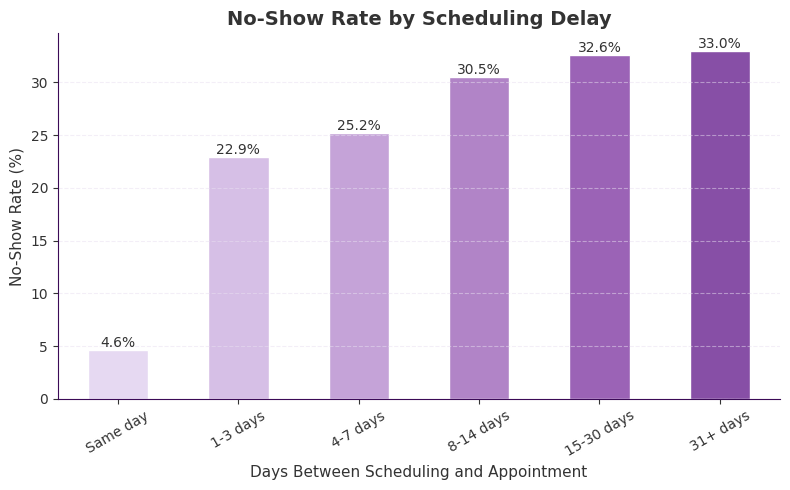

In [8]:
# EDA 1: No-show rate by scheduling delay group
delay_rate = clean_df.groupby('delay_group', observed=False)['no_show_flag'].mean() * 100

ax = delay_rate.plot(
    kind='bar',
    figsize=(8, 5),
    color=purple_palette,
    edgecolor="white"
)

plt.title('No-Show Rate by Scheduling Delay')
plt.xlabel('Days Between Scheduling and Appointment')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(delay_rate):
    if pd.notna(v):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Scheduling delay appears to be one of the strongest predictors of no-show behavior. Longer lead times are associated with higher no-show rates, suggesting that the time between scheduling and the appointment introduces greater uncertainty in patient attendance.

---

### Operational Takeaway

From an operational perspective, this suggests that clinics may benefit from prioritizing follow-up reminders or outreach for appointments scheduled further in advance.

---

### Transition to Next Analysis

While scheduling delay is a strong predictor, it is important to examine whether patient characteristics—such as age—also influence no-show behavior.

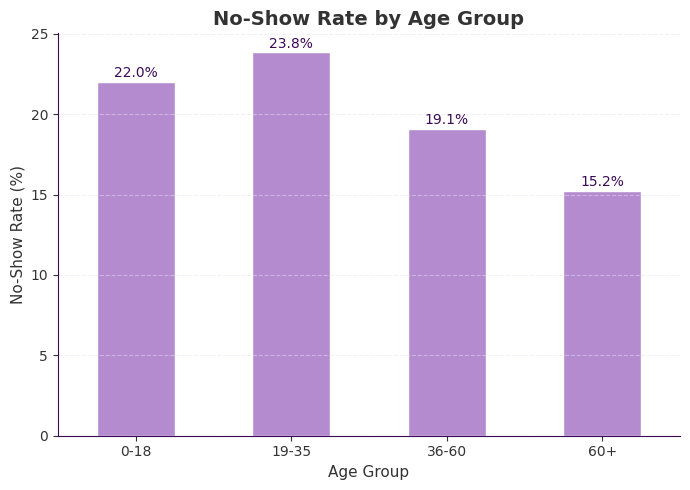

In [9]:
# EDA 2: No-show rate by age group
age_rate = clean_df.groupby('age_group', observed=False)['no_show_flag'].mean() * 100

ax = age_rate.plot(
    kind='bar',
    figsize=(7, 5),
    color=bar_purple,          # uses your theme color
    edgecolor="white"
)

plt.title('No-Show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Value labels (match darker purple tone)
for i, v in enumerate(age_rate):
    if pd.notna(v):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', color=dark_purple)

# Aesthetics
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Transition to Interaction Analysis

Since both scheduling delay and age appear to influence no-show rates, the next step is to examine how these variables interact and whether their combined effect provides additional insight into patient attendance behavior.

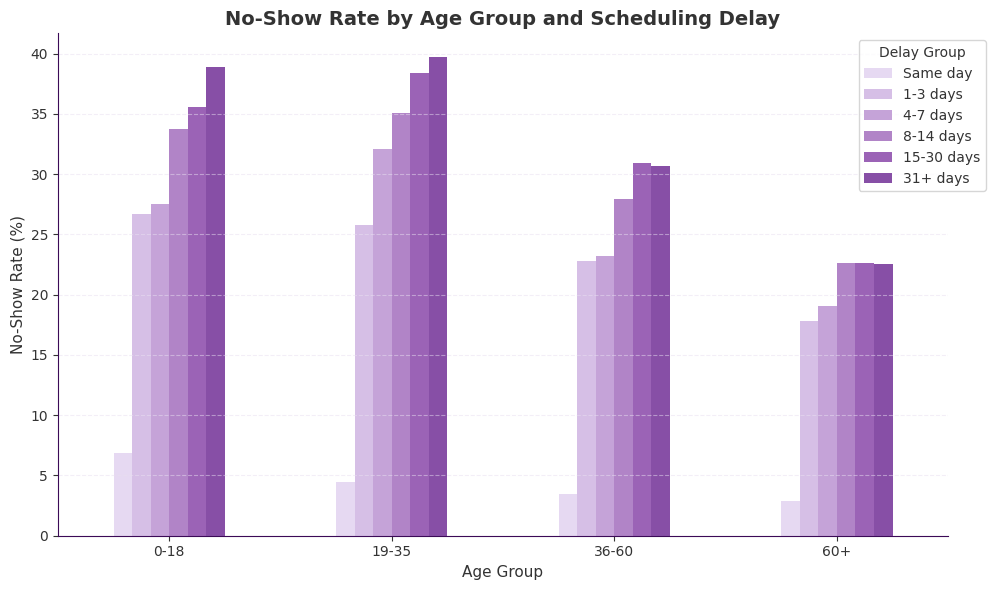

In [10]:
# EDA 3: Scheduling delay and age together (grouped bar chart)
age_delay_table = (
    clean_df
    .groupby(['age_group', 'delay_group'], observed=False)['no_show_flag']
    .mean()
    .mul(100)
    .unstack()
)

ax = age_delay_table.plot(
    kind='bar',
    figsize=(10, 6),
    color=purple_palette
)

plt.title('No-Show Rate by Age Group and Scheduling Delay')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Delay Group', bbox_to_anchor=(1.05, 1))

plt.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
age_delay_table.head()

delay_group,Same day,1-3 days,4-7 days,8-14 days,15-30 days,31+ days
age_group,,,,,,
0-18,6.838546,26.683292,27.544277,33.735312,35.609543,38.909917
19-35,4.480797,25.793506,32.056398,35.116044,38.376027,39.703065
36-60,3.497577,22.826482,23.196517,27.938969,30.939321,30.679934
60+,2.907370,17.856159,19.061086,22.637363,22.650177,22.561576


### Interpretation

This visualization shows how scheduling delay interacts with age to influence no-show rates. Across most age groups, longer delays are associated with higher no-show percentages, reinforcing the importance of lead time as a key predictor.

---

### Key Insight

These patterns suggest that demographic characteristics such as age influence appointment adherence, particularly when combined with scheduling factors. This supports including both demographic and operational variables in the predictive model.

---

### Operational Takeaway

This interaction highlights the potential value of targeted interventions. Rather than applying a uniform scheduling strategy, clinics may benefit from tailoring reminder systems and outreach efforts to specific patient groups based on both age and scheduling delay.

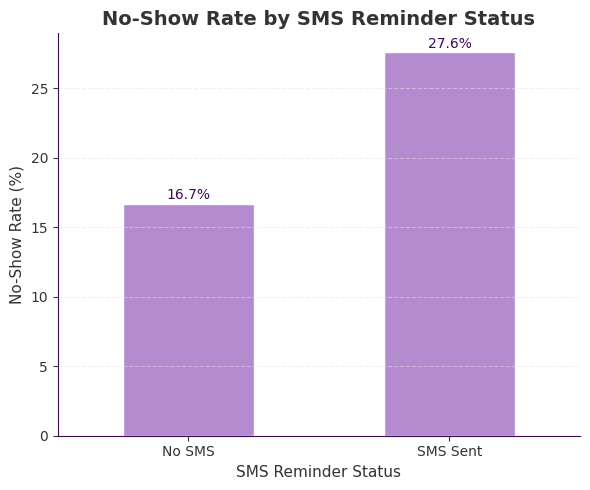

In [12]:
# EDA 4: No-show rate by SMS reminder status
sms_rate = clean_df.groupby('sms_received')['no_show_flag'].mean() * 100
sms_rate.index = ['No SMS', 'SMS Sent']

ax = sms_rate.plot(
    kind='bar',
    figsize=(6, 5),
    color=bar_purple,
    edgecolor="white"
)

plt.title('No-Show Rate by SMS Reminder Status')
plt.xlabel('SMS Reminder Status')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Value labels
for i, v in enumerate(sms_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', color=dark_purple)

# Aesthetics
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The relationship between SMS reminders and no-show rates must be interpreted carefully. A higher no-show rate among patients who received SMS reminders does not imply that reminders cause missed appointments.

---

### Key Insight

A more likely explanation is that SMS reminders are targeted toward patients or appointments already at higher risk, such as those scheduled farther in advance. This highlights a classic limitation of single-variable analysis: **correlation does not imply causation**.

---

### Modeling Implication

This reinforces the importance of multivariable modeling, where multiple features are considered simultaneously. By controlling for confounding factors, the model can better isolate the true relationships between predictors and no-show behavior.

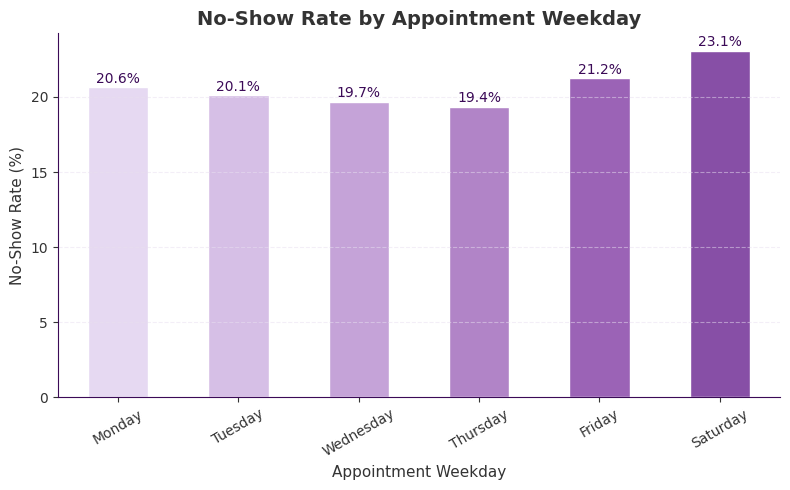

In [13]:
# EDA 5: No-show rate by appointment weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_rate = clean_df.groupby('appointment_weekday')['no_show_flag'].mean().reindex(weekday_order) * 100
weekday_rate = weekday_rate.dropna()

ax = weekday_rate.plot(
    kind='bar',
    figsize=(8, 5),
    color=purple_palette[:len(weekday_rate)],  # gradient effect
    edgecolor="white"
)

plt.title('No-Show Rate by Appointment Weekday')
plt.xlabel('Appointment Weekday')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Value labels
for i, v in enumerate(weekday_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', color=dark_purple)

# Aesthetics
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

This suggests that structural scheduling factors, such as day-of-week patterns, may influence appointment attendance.

---

### Key Insight

While the effect is smaller than variables like scheduling delay, weekday patterns may still provide **incremental predictive value** when included in a multivariable model.

## 6. Model Selection: Why Logistic Regression?

The final model uses **logistic regression** because the response variable is binary: an appointment is either missed or attended. This makes logistic regression a natural choice for a classification problem of this type.

---

### Why Logistic Regression?

Logistic regression is well-suited for this project because it is:

- **Interpretable** — coefficients can be directly related to changes in no-show risk  
- **Appropriate for classification** — designed for binary outcomes  
- **Widely used in healthcare and social science settings** where explanation and transparency are important  

---

### Trade-Off: Performance vs Interpretability

More complex models, such as random forests, could potentially improve predictive performance. However, the goal of this tutorial is not only prediction, but also **understanding which variables are associated with no-show risk**.

Logistic regression makes it easier to:
- connect model results back to EDA findings  
- interpret coefficients and direction of effects  
- translate results into operational recommendations  

---

### Evaluation Strategy

The model uses a **train/test split**, ensuring that performance is evaluated on data the model did not see during training. This addresses the need to move beyond exploratory analysis and demonstrate true predictive capability.

---

### Key Takeaway

While performance is moderate, the model prioritizes **interpretability**, which is critical in healthcare decision-making contexts where understanding *why* a prediction is made is just as important as the prediction itself.

In [14]:
# Select model features
# These are chosen because EDA and domain reasoning suggest they may relate to no-show behavior.
features = [
    'age',
    'lead_time_days',
    'sms_received',
    'appointment_weekday',
    'scholarship',
    'hipertension',
    'diabetes',
    'alcoholism',
    'handcap'
]

target = 'no_show_flag'

# Drop rows with missing values in the selected columns
model_df = clean_df[features + [target]].dropna().copy()

X = model_df[features]
y = model_df[target]

print(f"Modeling rows: {len(model_df):,}")
print(f"No-show rate in modeling data: {y.mean() * 100:.2f}%")

Modeling rows: 110,521
No-show rate in modeling data: 20.19%


In [15]:
# Identify numeric and categorical features
numeric_features = ['age', 'lead_time_days']
categorical_features = [
    'sms_received',
    'appointment_weekday',
    'scholarship',
    'hipertension',
    'diabetes',
    'alcoholism',
    'handcap'
]

# Preprocessing: scale numeric variables and one-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Logistic regression pipeline
log_reg_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
)

In [16]:
# Train/test split
# Stratify preserves the same approximate no-show rate in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Training no-show rate: {y_train.mean() * 100:.2f}%")
print(f"Testing no-show rate: {y_test.mean() * 100:.2f}%")

Training rows: 82,890
Testing rows: 27,631
Training no-show rate: 20.19%
Testing no-show rate: 20.19%


In [17]:
# Fit the model
log_reg_model.fit(X_train, y_train)

# Predictions
predicted_labels = log_reg_model.predict(X_test)
predicted_probabilities = log_reg_model.predict_proba(X_test)[:, 1]

In [18]:
# Model evaluation metrics
metrics = {
    'Accuracy': accuracy_score(y_test, predicted_labels),
    'Precision': precision_score(y_test, predicted_labels),
    'Recall': recall_score(y_test, predicted_labels),
    'F1 Score': f1_score(y_test, predicted_labels),
    'ROC-AUC': roc_auc_score(y_test, predicted_probabilities)
}

metrics_df = pd.DataFrame(metrics, index=['Logistic Regression']).T
metrics_df

,Logistic Regression
Accuracy,0.664399
Precision,0.314484
Recall,0.561212
F1 Score,0.403090
ROC-AUC,0.666188


### Interpreting the Metrics

Accuracy alone can be misleading in this context because most patients attend their appointments. A model that predicts every patient will attend could achieve high accuracy while failing to identify missed appointments.

---

### Why Multiple Metrics Matter

To address this, the model is evaluated using:

- **Precision** — how many predicted no-shows are actually correct  
- **Recall** — how many true no-shows are successfully identified  
- **F1 Score** — balance between precision and recall  
- **ROC-AUC** — overall ability to distinguish between classes  

---

### Key Metric: Recall

For this project, **recall** is especially important because it measures how many true no-shows the model captures. In a clinical workflow, failing to identify a high-risk appointment could mean missing an opportunity to send an additional reminder or provide support.

---

### Operational Trade-Off

Precision is also important, since too many false positives could lead to unnecessary outreach and inefficient use of staff time. In practice, the most effective model would balance recall with available operational resources and outreach capacity.

In [19]:
# Classification report
print(classification_report(y_test, predicted_labels, target_names=['Attended', 'No-show']))

              precision    recall  f1-score   support

    Attended       0.86      0.69      0.77     22052
     No-show       0.31      0.56      0.40      5579

    accuracy                           0.66     27631
   macro avg       0.59      0.63      0.58     27631
weighted avg       0.75      0.66      0.69     27631



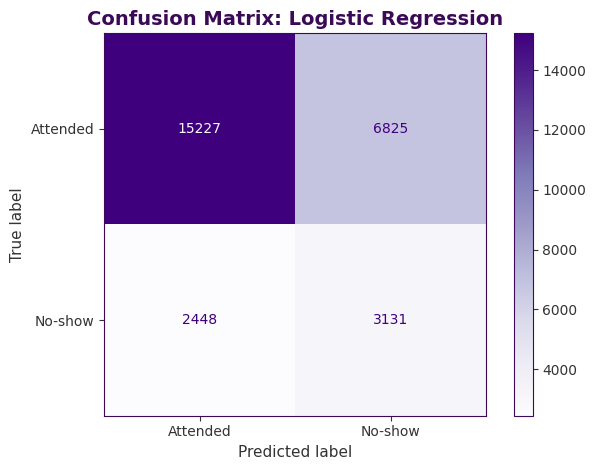

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Attended', 'No-show']
)

disp.plot(
    cmap="Purples",
    values_format='d'
)

plt.title('Confusion Matrix: Logistic Regression', color=dark_purple)

# Aesthetics for consistency
plt.grid(False)

plt.tight_layout()
plt.show()

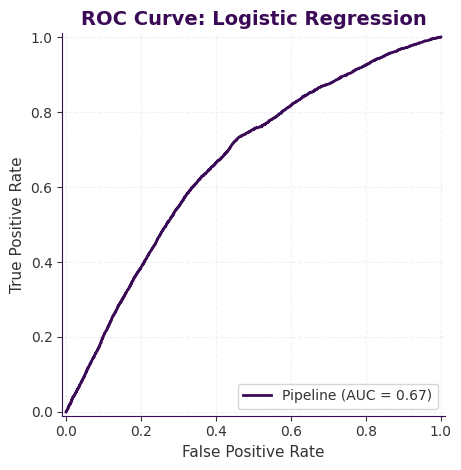

In [21]:
# ROC curve
RocCurveDisplay.from_estimator(
    log_reg_model,
    X_test,
    y_test,
    color=dark_purple,
    linewidth=2
)

plt.title('ROC Curve: Logistic Regression', color=dark_purple)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Lavender grid
plt.grid(True, linestyle='--', alpha=0.5)

# Clean aesthetic
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Model Performance Summary

The logistic regression model demonstrates **moderate predictive performance**, with balanced trade-offs between accuracy, precision, and recall.

---

### Key Insight

While accuracy provides a general sense of correctness, **recall is especially important** in this context because it reflects how well the model identifies patients who will miss their appointments. The model’s recall suggests that a meaningful portion of high-risk no-shows can be detected in advance, creating opportunities for targeted intervention.

---

### Context and Positioning

Compared to more complex healthcare prediction models, this approach should be viewed as a **strong, interpretable baseline** rather than a maximum-performance solution.

---

### Final Takeaway

Overall, these results support the idea that even relatively simple models can capture meaningful patterns in patient behavior and provide actionable insights for improving clinic operations.

## 7. Feature Interpretation

Because logistic regression is an **interpretable model**, its coefficients can be used to understand how different features contribute to predicted no-show risk.

---

### How to Interpret Coefficients

- **Positive coefficients** increase the predicted log-odds of a no-show  
- **Negative coefficients** decrease the predicted log-odds of a no-show  

This allows the model to provide insight into which factors are associated with higher or lower attendance risk.

---

### Standardization and Comparability

Since numeric features were **standardized**, the magnitudes of coefficients are more directly comparable across variables such as age and scheduling delay. This makes it easier to assess which features have relatively stronger influence on predictions.

---

### Key Takeaway

Feature interpretation helps bridge the gap between prediction and explanation, allowing model outputs to be translated into meaningful, actionable insights for clinic operations.

In [22]:
# Extract feature names after preprocessing
feature_names = log_reg_model.named_steps['preprocess'].get_feature_names_out()
coefficients = log_reg_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
}).sort_values('coefficient', ascending=False)

coef_df.head(15)

,feature,coefficient,odds_ratio
1,num__lead_time_days,0.420623,1.522909
2,cat__sms_received_1,0.389127,1.475692
8,cat__scholarship_1,0.235316,1.265308
11,cat__alcoholism_1,0.189798,1.209005
10,cat__diabetes_1,0.100565,1.105796
12,cat__handcap_1,0.036749,1.037433
4,cat__appointment_weekday_Saturday,0.014667,1.014775
13,cat__handcap_2,0.012104,1.012177
14,cat__handcap_3,0.003744,1.003751
9,cat__hipertension_1,0.000042,1.000042


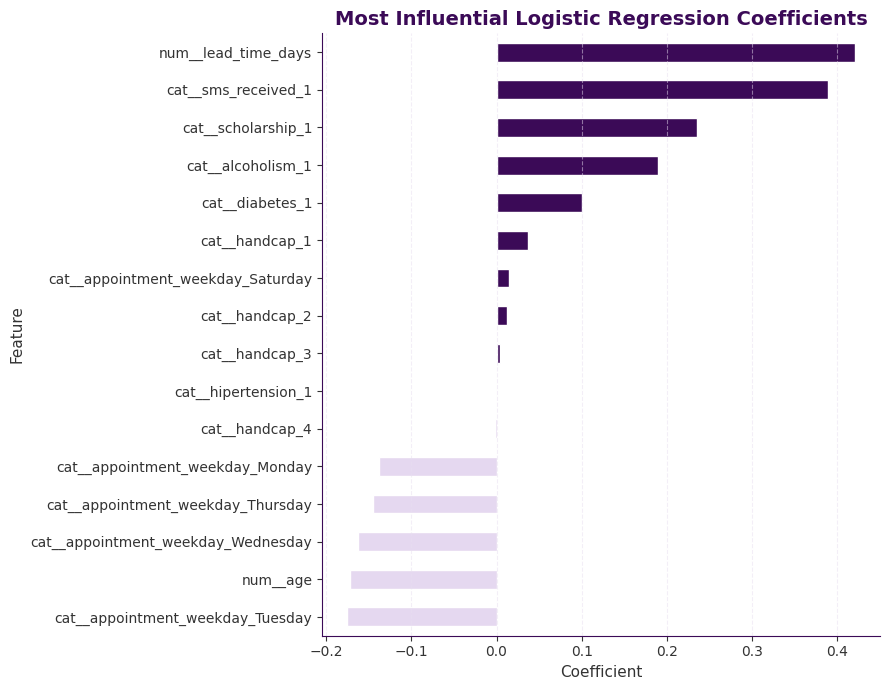

In [23]:
# Visualize the most influential positive and negative coefficients
coef_plot_df = pd.concat([
    coef_df.head(8),
    coef_df.tail(8)
]).sort_values('coefficient')

# Color bars based on sign
colors = [
    dark_purple if val > 0 else light_purple
    for val in coef_plot_df['coefficient']
]

ax = coef_plot_df.plot(
    x='feature',
    y='coefficient',
    kind='barh',
    figsize=(9, 7),
    color=colors,
    edgecolor="white",
    legend=False
)

plt.title('Most Influential Logistic Regression Coefficients', color=dark_purple)
plt.xlabel('Coefficient')
plt.ylabel('Feature')

# Aesthetics
plt.grid(axis='x', linestyle='--', alpha=0.5)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Conclusions and Recommendations

This project demonstrates that medical appointment no-shows can be understood as both an operational healthcare challenge and a predictive data science problem. The exploratory analysis identified several meaningful predictors of attendance, including scheduling delay, age, SMS reminder status, weekday, and health/social indicators. The logistic regression model then tested whether these variables could be used together to predict no-show risk on unseen data.

---

### Key Findings

**1. Scheduling delay is the strongest operational signal**  
Appointments scheduled far in advance are associated with higher no-show rates. Longer lead times introduce more opportunities for scheduling conflicts, transportation issues, or loss of urgency.  
→ *Operational takeaway:* Clinics may benefit from prioritizing follow-up reminders or outreach for long-delay appointments.

**2. Age and demographic factors contribute to risk patterns**  
No-show behavior varies across age groups, suggesting that patient characteristics influence attendance.  
→ *Operational takeaway:* Different patient populations may benefit from tailored scheduling or reminder strategies.

**3. SMS reminders require careful interpretation**  
Higher no-show rates among patients receiving SMS reminders do not imply that reminders are ineffective. Instead, reminders may be targeted toward already high-risk patients.  
→ *Key insight:* This highlights the importance of multivariable modeling rather than relying on single-variable conclusions.

---

### Practical Recommendations

Based on these findings, clinics could consider:

- **Targeted reminder strategies** for patients with long scheduling delays  
- **Follow-up outreach closer to appointment dates**  
- **Flexible rescheduling or waitlist systems** to re-engage patients  
- **Use of predictive risk scores** within scheduling systems to identify high-risk appointments  

More advanced systems could integrate these predictions directly into scheduling dashboards, allowing staff to proactively manage attendance risk.

These strategies align with findings in healthcare research, where predictive models have been shown to improve attendance rates and overall clinic efficiency when used as decision-support tools ([Healthcare Study on Predictive No-Show Modeling](https://pmc.ncbi.nlm.nih.gov/articles/PMC11545362/)).

---

### Limitations

- This analysis is **observational**, so it identifies associations rather than causal relationships  
- The dataset is based on a **Brazilian healthcare system**, which may limit generalizability  
- The supplemental socioeconomic dataset was **too small for strong conclusions**  
- Additional features such as distance to clinic, appointment type, and prior attendance history were not included  

Future work could improve predictive performance by incorporating these additional variables.

---

### Final Takeaway

Even relatively simple, interpretable models like logistic regression can uncover meaningful patterns in patient behavior. When used responsibly, these insights can support more efficient scheduling systems, improve patient access to care, and reduce missed appointments without penalizing patients.

---

## References

### Healthcare Research & Real-World Applications

- [Healthcare Study on Predictive No-Show Modeling](https://pmc.ncbi.nlm.nih.gov/articles/PMC11545362/)  
  This study supports the use of predictive models as decision-support tools in healthcare settings, demonstrating improvements in patient attendance and operational efficiency.

- [How Machine Learning Can Predict Patient No-Shows (AAPC)](https://www.aapc.com/blog/93112-can-machine-learning-predict-patient-no-shows/)  
  This article highlights how predictive analytics can be used in practice to identify high-risk patients and guide targeted interventions such as reminders and scheduling adjustments.